segment_agland.py -- James Sayre, sayrejay@pm.me

Intersect ADCs with agmask information.

In [ ]:
### Programs
import os, sys
os.environ['USE_PYGEOS'] = '0'
import regionmask
import geopandas as gpd, fiona
fiona.drvsupport.supported_drivers['libkml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw' # enable KML support which is disabled by default
import xarray as xr
from shapely.geometry import Polygon
from shapely.geometry import Point
from shapely.ops import cascaded_union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

### Directories
topdir             =  os.path.join(os.path.expanduser("~"), "Dropbox", "Projects")
projectdir         =  os.path.join(topdir,     "Maize_prediction")
cropdir            =  os.path.join(topdir,    "Crop_misallocation")
sciagadir          =  os.path.join(cropdir,   "data", "SCIAGA")
datadir            =  os.path.join(projectdir, "Data")
agland_dir         =  os.path.join(datadir,    "SIAP_agland", "Input")
agland_out_dir     =  os.path.join(datadir,    "SIAP_agland", "Output")
maize_dir          =  os.path.join(datadir,    "SIAP_maize_land", "Input")
maize_out_dir      =  os.path.join(datadir,    "SIAP_maize_land", "Output")
mexico_dir         =  os.path.join(datadir,    "Mexico_agland","Outputs")
inegi_dir          =  os.path.join(datadir,    "INEGI")
amcadir            =  os.path.join(inegi_dir,  "Areas_Censal_Agropecuario_2016")
md_dir             =  os.path.join(inegi_dir,  "MD_lab_outputs", "AMCA_ADC_data_2022-11-23")
marco_geo_22_dir   =  os.path.join(inegi_dir,  "Marco_Geo_2022")
marco_geo_inp_dir  =  os.path.join(marco_geo_22_dir, "Inputs")
marco_geo_out_dir  =  os.path.join(marco_geo_22_dir, "Outputs")

### Inputs
agland_shp_siap    =  os.path.join(agland_out_dir,    "agland_siap.shp") ### SIAP agland data
ageb_22_shp        =  os.path.join(marco_geo_inp_dir, "00a.shp")
        
### Outputs
ageb_22_out_shp    =  os.path.join(marco_geo_out_dir, "ageb_22.shp")
muns_from_agebs22  =  os.path.join(marco_geo_out_dir, "muns_ca22.shp")
ageb22_agland_shp  =  os.path.join(marco_geo_out_dir, "ageb_22_agland.shp")
mun22_agland_shp   =  os.path.join(marco_geo_out_dir, "mun_22_agland.shp")

In [3]:
### Clean 2022 CA AGEB data
ageb_22_df = gpd.read_file(ageb_22_shp)
ageb_22_df = ageb_22_df[ageb_22_df['AMBITO'] == 'Rural']
ageb_22_df['ha_area'] = ageb_22_df.to_crs(epsg=6372).geometry.area/10000.0
ageb_22_df['muncode'] = ageb_22_df['CVE_ENT']+ageb_22_df['CVE_MUN']
ageb_22_df['ageb'] = ageb_22_df['CVE_ENT']+ageb_22_df['CVE_MUN']+ageb_22_df['CVE_AGEB'].apply(lambda x: x[:3])+'-'+ageb_22_df['CVE_AGEB'].apply(lambda x: x[3:])
ageb_22_df = ageb_22_df.drop(['CVE_ENT','CVE_MUN','CVE_LOC','CVE_AGEB','AMBITO'],axis=1)
ageb_22_df = ageb_22_df.reset_index(drop=True)
ageb_22_df.to_file(ageb_22_out_shp, write_index=False)

## Produce 2022 municipality shapefile from 2022 AGEBS
mun_22_df = gpd.read_file(ageb_22_out_shp)[['muncode','geometry']]
mun_22_df = mun_22_df.dissolve('muncode').reset_index()
mun_22_df['ha_area'] = mun_22_df.to_crs(epsg=6372).geometry.area/10000.0
mun_22_df.to_file(muns_from_agebs22,write_index=False)

In [ ]:
### Produce size statistics for AGEBs
ageb_22_df['ha_area'].median(), ageb_22_df['ha_area'].min(), ageb_22_df['ha_area'].max()

In [4]:
### Merge AGEBS and muns. with SIAP agland data
agland_df  =  gpd.read_file(agland_shp_siap)
ageb_22_df =  ageb_22_df.to_crs(agland_df.crs)
ageb_agland_df = gpd.overlay(ageb_22_df[['ageb','geometry']], agland_df, how='intersection')
ageb_agland_df = ageb_agland_df.drop(['ag_o_past','irrig','cntry'],axis=1)
ageb_agland_df['siap_agland_area'] = ageb_agland_df.to_crs(epsg=6372).geometry.area/10000.0
ageb_agland_df.to_file(ageb22_agland_shp, write_index=False)
ageb_agland_df['muncode'] = ageb_agland_df['ageb'].apply(lambda x: x[:5])
mun_agland_df = ageb_agland_df.dissolve('muncode').reset_index()
mun_agland_df = mun_agland_df.drop(['ageb','siap_agland_area'],axis=1)
mun_agland_df.to_file(mun22_agland_shp,  write_index=False)

/tmp/ipykernel_8668/582077285.py:4: UserWarning: `keep_geom_type=True` in overlay resulted in 718 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  ageb_agland_df = gpd.overlay(ageb_22_df[['ageb','geometry']], agland_df, how='intersection')


/tmp/ipykernel_66701/3486229767.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


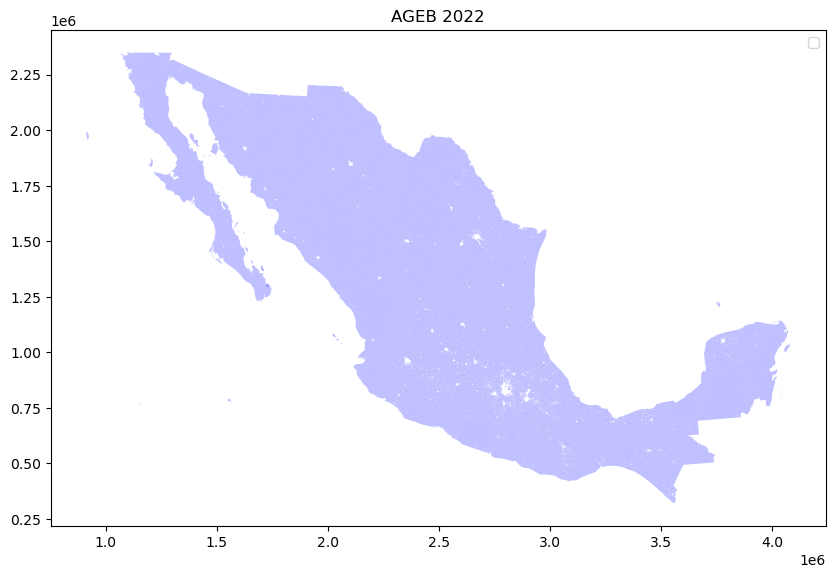

In [15]:

fig, ax = plt.subplots(figsize=(10, 10))

# Set the latitude and longitude limits
# ax.set_xlim(4.021919e+06, 4.064853e+06)
# ax.set_ylim(1.102705e+06, 1.134082e+06)

ageb_22_df.plot(ax=ax, color='blue', alpha=0.25, label='AGEBS', legend=True)

plt.legend()

plt.title('AGEB 2022')

# Show the plot
plt.show()
